# Aula 05 — Redução de Dimensionalidade Avançada

**Disciplina:** Operacionalização de Modelos com MLOps  
**Pré-requisito:** Fundamentos de Machine Learning com scikit-learn

---

## Objetivos desta aula

Ao final desta aula, você será capaz de:

- Compreender o problema da maldição da dimensionalidade e seu impacto na modelagem
- Aplicar **PCA** e **Kernel PCA** para redução linear e não-linear de dimensões
- Utilizar **LDA** para maximizar a separabilidade entre classes antes da classificação
- Empregar **t-SNE** e **UMAP** para visualização e exploração de estruturas ocultas
- Construir **Pipelines** completos integrando redução de dimensionalidade com classificadores
- Comparar as técnicas e escolher a mais adequada para cada cenário

---

## 0. Configuração do Ambiente

In [29]:
import os
import zipfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from dotenv import load_dotenv

# --- Scikit-learn ---
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report

import umap

# Estilo visual
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = 'tab10'
SEED = 42

In [30]:
# carregando as credenciais do Kaggle
load_dotenv('secrets.env')

print('Usuário Kaggle: ', os.getenv('KAGGLE_USERNAME'))

Usuário Kaggle:  iaugustomz


In [31]:
import kaggle

# Dataset: Human Activity Recognition with Smartphones (UCI)
# 561 features de sensores de smartphone + labels de atividade física
DATASET = 'uciml/human-activity-recognition-with-smartphones'
DATA_DIR = 'data'

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

if not os.path.exists(os.path.join(DATA_DIR, 'train.csv')):
    print('Baixando dataset do Kaggle...')
    kaggle.api.dataset_download_files(DATASET, path=DATA_DIR, unzip=True)
    print('Download concluído!')
else:
    print('Dataset já disponível localmente.')

Dataset já disponível localmente.


---

## 1. Introdução: A Maldição da Dimensionalidade

### 1.1 O problema

Quando trabalhamos com dados de alta dimensão — como sinais de sensores, imagens ou texto vetorizado — nos deparamos com um fenômeno contraintuitivo chamado **maldição da dimensionalidade** (*curse of dimensionality*).

A intuição é a seguinte: imagine que você quer cobrir 10% do volume de um hipercubo unitário em $d$ dimensões. O lado $\ell$ do sub-hipercubo necessário cresce exponencialmente:

$$\ell = 0{,}1^{1/d}$$

| $d$ | $\ell$ |
|-----|--------|
| 1   | 0,10   |
| 2   | 0,32   |
| 10  | 0,80   |
| 100 | 0,977  |

Em 100 dimensões, precisamos cobrir **97,7%** de cada eixo para capturar apenas 10% dos dados. Isso significa que **os dados se tornam extremamente esparsos** conforme o número de features cresce.

### 1.2 Consequências práticas para a modelagem

Essa esparsidade tem efeitos diretos no desempenho dos modelos:

1. **Overfitting:** Com muitas features, o modelo encontra padrões espúrios no ruído
2. **Distâncias perdem significado:** Em alta dimensão, todos os pontos ficam aproximadamente à mesma distância, quebrando algoritmos baseados em vizinhança (KNN, K-Means, SVM)
3. **Custo computacional:** Treinar e predizer em 561 features é muito mais lento do que em 50
4. **Multicolinearidade:** Features altamente correlacionadas inflam variâncias e instabilizam coeficientes

A equação da variância de um estimador em alta dimensão reflete isso:

$$\text{Var}(\hat{f}(x)) \propto \frac{d}{n}$$

onde $d$ é o número de features e $n$ o número de amostras. Reduzir $d$ é uma forma direta de reduzir a variância do modelo.

### 1.3 Duas estratégias principais

| Estratégia | Ideia | Exemplos |
|---|---|---|
| **Projeção** | Achata os dados em subespaços lineares ou não-lineares | PCA, Kernel PCA, LDA |
| **Manifold Learning** | Desdobra estruturas curvas preservando vizinhança local | t-SNE, UMAP, LLE |

> **Regra prática:** Use projeção quando precisa de um espaço reduzido para treinar modelos em produção. Use manifold learning para exploração e visualização — seus resultados geralmente não são estáveis ou invertíveis o suficiente para uso direto em pipelines.

---

## 2. O Dataset: Reconhecimento de Atividade Humana (HAR)

O dataset HAR contém medições de **acelerômetro** e **giroscópio** de um smartphone carregado por 30 voluntários realizando 6 atividades físicas. Cada amostra possui **561 features** extraídas no domínio do tempo e da frequência.

**Por que este dataset é ideal para esta aula?**
- Alta dimensionalidade real (561 features)
- Features altamente correlacionadas (ruído de sensor)
- 6 classes balanceadas — perfeito para LDA e visualização
- Contexto físico interpretável: aceleração, rotação, frequência

In [32]:
# Carregamento dos dados
df_train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

# Separa features e target
TARGET = 'Activity'
X_train = df_train.drop(columns=[TARGET, 'subject'])
y_train = df_train[TARGET]
X_test  = df_test.drop(columns=[TARGET, 'subject'])
y_test  = df_test[TARGET]

print(f'Treino: {X_train.shape[0]} amostras, {X_train.shape[1]} features')
print(f'Teste:  {X_test.shape[0]} amostras, {X_test.shape[1]} features')
print(f'\nDistribuição das classes (treino):')
print(y_train.value_counts())

Treino: 7352 amostras, 561 features
Teste:  2947 amostras, 561 features

Distribuição das classes (treino):
Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


In [33]:
X_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,tBodyAcc-max()-Y,tBodyAcc-max()-Z,tBodyAcc-min()-X,tBodyAcc-min()-Y,tBodyAcc-min()-Z,tBodyAcc-sma(),tBodyAcc-energy()-X,tBodyAcc-energy()-Y,tBodyAcc-energy()-Z,tBodyAcc-iqr()-X,tBodyAcc-iqr()-Y,tBodyAcc-iqr()-Z,tBodyAcc-entropy()-X,tBodyAcc-entropy()-Y,tBodyAcc-entropy()-Z,"tBodyAcc-arCoeff()-X,1","tBodyAcc-arCoeff()-X,2","tBodyAcc-arCoeff()-X,3","tBodyAcc-arCoeff()-X,4","tBodyAcc-arCoeff()-Y,1","tBodyAcc-arCoeff()-Y,2","tBodyAcc-arCoeff()-Y,3","tBodyAcc-arCoeff()-Y,4","tBodyAcc-arCoeff()-Z,1","tBodyAcc-arCoeff()-Z,2","tBodyAcc-arCoeff()-Z,3","tBodyAcc-arCoeff()-Z,4","tBodyAcc-correlation()-X,Y","tBodyAcc-correlation()-X,Z","tBodyAcc-correlation()-Y,Z",...,fBodyBodyAccJerkMag-energy(),fBodyBodyAccJerkMag-iqr(),fBodyBodyAccJerkMag-entropy(),fBodyBodyAccJerkMag-maxInds,fBodyBodyAccJerkMag-meanFreq(),fBodyBodyAccJerkMag-skewness(),fBodyBodyAccJerkMag-kurtosis(),fBodyBodyGyroMag-mean(),fBodyBodyGyroMag-std(),fBodyBodyGyroMag-mad(),fBodyBodyGyroMag-max(),fBodyBodyGyroMag-min(),fBodyBodyGyroMag-sma(),fBodyBodyGyroMag-energy(),fBodyBodyGyroMag-iqr(),fBodyBodyGyroMag-entropy(),fBodyBodyGyroMag-maxInds,fBodyBodyGyroMag-meanFreq(),fBodyBodyGyroMag-skewness(),fBodyBodyGyroMag-kurtosis(),fBodyBodyGyroJerkMag-mean(),fBodyBodyGyroJerkMag-std(),fBodyBodyGyroJerkMag-mad(),fBodyBodyGyroJerkMag-max(),fBodyBodyGyroJerkMag-min(),fBodyBodyGyroJerkMag-sma(),fBodyBodyGyroJerkMag-energy(),fBodyBodyGyroJerkMag-iqr(),fBodyBodyGyroJerkMag-entropy(),fBodyBodyGyroJerkMag-maxInds,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,-0.567378,-0.744413,0.852947,0.685845,0.814263,-0.965523,-0.999945,-0.999863,-0.994612,-0.994231,-0.987614,-0.943220,-0.407747,-0.679338,-0.602122,0.929294,-0.853011,0.359910,-0.058526,0.256892,-0.224848,0.264106,-0.095246,0.278851,-0.465085,0.491936,-0.190884,0.376314,0.435129,0.660790,...,-0.999918,-0.991364,-1.0,-0.936508,0.346989,-0.516080,-0.802760,-0.980135,-0.961309,-0.973653,-0.952264,-0.989498,-0.980135,-0.999240,-0.992656,-0.701291,-1.000000,-0.128989,0.586156,0.374605,-0.991990,-0.990697,-0.989941,-0.992448,-0.991048,-0.991990,-0.999937,-0.990458,-0.871306,-1.000000,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,-0.557851,-0.818409,0.849308,0.685845,0.822637,-0.981930,-0.999991,-0.999788,-0.998405,-0.999150,-0.977866,-0.948225,-0.714892,-0.500930,-0.570979,0.611627,-0.329549,0.284213,0.284595,0.115705,-0.090963,0.294310,-0.281211,0.085988,-0.022153,-0.016657,-0.220643,-0.013429,-0.072692,0.579382,...,-0.999867,-0.991134,-1.0,-0.841270,0.532061,-0.624871,-0.900160,-0.988296,-0.983322,-0.982659,-0.986321,-0.991829,-0.988296,-0.999811,-0.993979,-0.720683,-0.948718,-0.271958,-0.336310,-0.720015,-0.995854,-0.996399,-0.995442,-0.996866,-0.994440,-0.995854,-0.999981,-0.994544,-1.000000,-1.000000,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,-0.557851,-0.818409,0.843609,0.682401,0.839344,-0.983478,-0.999969,-0.999660,-0.999470,-0.997130,-0.964810,-0.974675,-0.592235,-0.485821,-0.570979,0.273025,-0.086309,0.337202,-0.164739,0.017150,-0.074507,0.342256,-0.332564,0.239281,-0.136204,0.173863,-0.299493,-0.124698,-0.181105,0.608900,...,-0.999845,-0.986658,-1.0,-0.904762,0.660795,-0.724697,-0.928539,-0.989255,-0.986

In [34]:
# padronizar a coloração dos plots
CLASSES = list(y_train.unique())
COLORS  = dict(zip(CLASSES, sns.color_palette(PALETTE, len(CLASSES))))

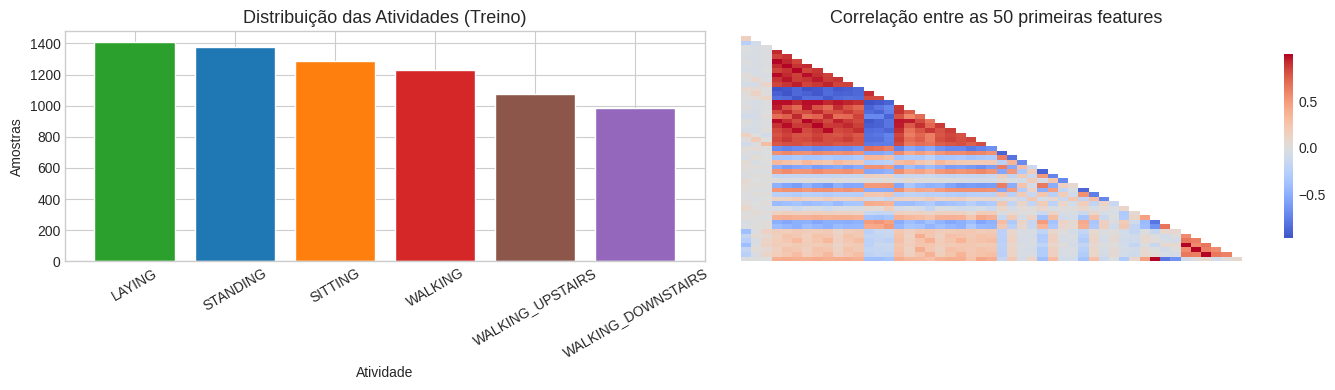


Observação: a matriz de correlação revela blocos de alta correlação,
confirmando que as 561 features carregam informação redundante.


In [35]:
# ── Visualização 1: Distribuição das classes ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Contagem
counts = y_train.value_counts()
axes[0].bar(counts.index, counts.values,
            color=[COLORS[c] for c in counts.index], edgecolor='white')
axes[0].set_title('Distribuição das Atividades (Treino)', fontsize=13)
axes[0].set_xlabel('Atividade')
axes[0].set_ylabel('Amostras')
axes[0].tick_params(axis='x', rotation=30)

# Heatmap de correlação média por grupo de features
# (amostramos 50 features para legibilidade)
sample_cols = X_train.columns[:50]
corr = X_train[sample_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False, cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlação entre as 50 primeiras features', fontsize=13)

plt.tight_layout()
plt.show()

print('\nObservação: a matriz de correlação revela blocos de alta correlação,')
print('confirmando que as 561 features carregam informação redundante.')

In [36]:
# Pré-processamento base: escalonamento
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

---

## 3. PCA — Análise de Componentes Principais

### 3.1 Fundamentos matemáticos

O PCA busca uma transformação linear ortogonal que projeta os dados em um novo espaço onde as **direções de máxima variância** são os eixos principais.

Dado um conjunto de dados centrado $\mathbf{X} \in \mathbb{R}^{n \times d}$, a matriz de covariância é:

$$\mathbf{C} = \frac{1}{n-1} \mathbf{X}^\top \mathbf{X}$$

O PCA resolve o problema de autodecomposição:

$$\mathbf{C}\, \mathbf{v}_k = \lambda_k\, \mathbf{v}_k$$

onde $\lambda_k$ é o **autovalor** (variância capturada) e $\mathbf{v}_k$ é o **autovetor** (direção da componente principal $k$).

A **variância explicada acumulada** por $K$ componentes é:

$$\text{VEA}(K) = \frac{\sum_{k=1}^{K} \lambda_k}{\sum_{k=1}^{d} \lambda_k}$$

### 3.2 O que o PCA faz fisicamente?

No contexto do dataset HAR, as componentes principais correspondem a **combinações lineares dos sinais de sensor** que explicam o máximo de variação entre os voluntários e atividades. Fisicamente:

- **PC1** tende a capturar a intensidade geral do movimento (atividades estáticas vs. dinâmicas)
- **PC2** tende a capturar a direção do movimento (vertical vs. horizontal)
- Componentes posteriores capturam padrões mais sutis de frequência e rotação

### 3.3 Por que isso beneficia a modelagem?

- Elimina multicolinearidade: as componentes são **ortogonais por construção**
- Reduz overfitting ao descartar componentes de baixa variância (ruído de sensor)
- Acelera o treinamento reduzindo o espaço de entrada de 561 para ~50-100 dimensões
- Estabiliza algoritmos sensíveis a escala (SVM, regressão logística)

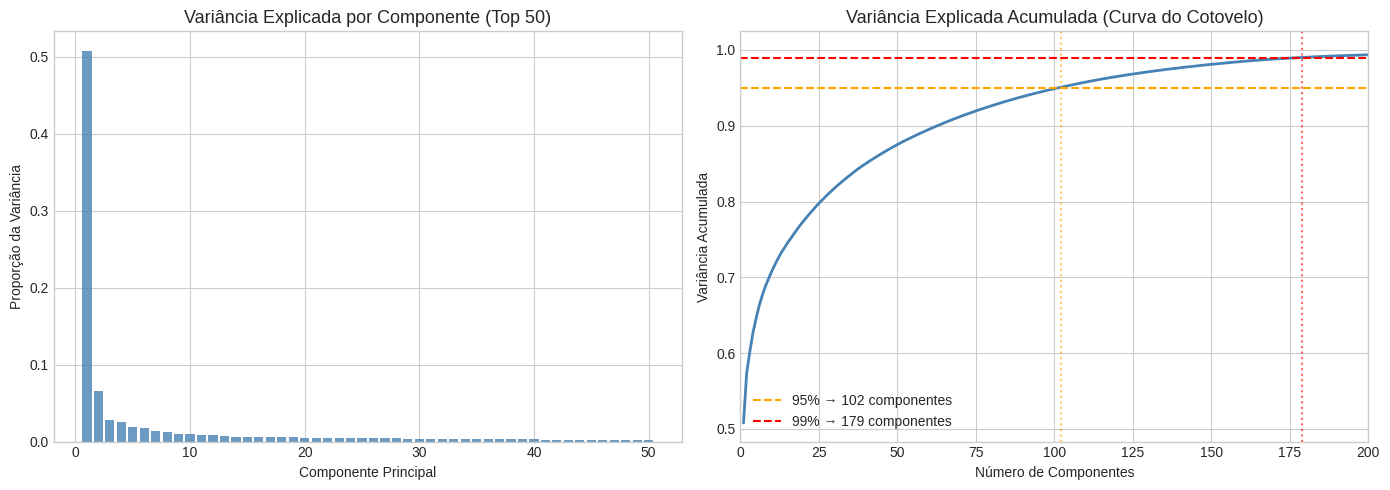

Para capturar 95% da variância: 102 componentes (de 561)
Para capturar 99% da variância: 179 componentes (de 561)

Redução de dimensionalidade: 561 → 102 features para 95% de variância
Isso é uma compressão de 81.8%!


In [37]:
# ── PCA: variância explicada ──────────────────────────────────────────────────
pca_full = PCA(random_state=SEED)
pca_full.fit(X_train_sc)

var_exp   = pca_full.explained_variance_ratio_
var_acum  = np.cumsum(var_exp)

# Número de componentes para 95% e 99% de variância
n_95 = np.argmax(var_acum >= 0.95) + 1
n_99 = np.argmax(var_acum >= 0.99) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variância individual
axes[0].bar(range(1, 51), var_exp[:50], color='steelblue', alpha=0.8)
axes[0].set_title('Variância Explicada por Componente (Top 50)', fontsize=13)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Proporção da Variância')

# Variância acumulada
axes[1].plot(range(1, len(var_acum) + 1), var_acum, color='steelblue', lw=2)
axes[1].axhline(0.95, color='orange', ls='--', label=f'95% → {n_95} componentes')
axes[1].axhline(0.99, color='red',    ls='--', label=f'99% → {n_99} componentes')
axes[1].axvline(n_95, color='orange', ls=':', alpha=0.6)
axes[1].axvline(n_99, color='red',    ls=':', alpha=0.6)
axes[1].set_title('Variância Explicada Acumulada (Curva do Cotovelo)', fontsize=13)
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Acumulada')
axes[1].legend()
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.show()

print(f'Para capturar 95% da variância: {n_95} componentes (de 561)')
print(f'Para capturar 99% da variância: {n_99} componentes (de 561)')
print(f'\nRedução de dimensionalidade: {561} → {n_95} features para 95% de variância')
print(f'Isso é uma compressão de {(1 - n_95/561)*100:.1f}%!')

In [38]:
# ── PCA via Pipeline ─────────────────────────────────────────────────────────
# Usamos n_components=0.95 para reter automaticamente 95% da variância
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95, random_state=SEED)),
])

X_train_pca = pipe_pca.fit_transform(X_train)
X_test_pca  = pipe_pca.transform(X_test)

n_comp_final = pipe_pca.named_steps['pca'].n_components_
print(f'Pipeline PCA → dimensão reduzida: {n_comp_final} componentes')

Pipeline PCA → dimensão reduzida: 102 componentes


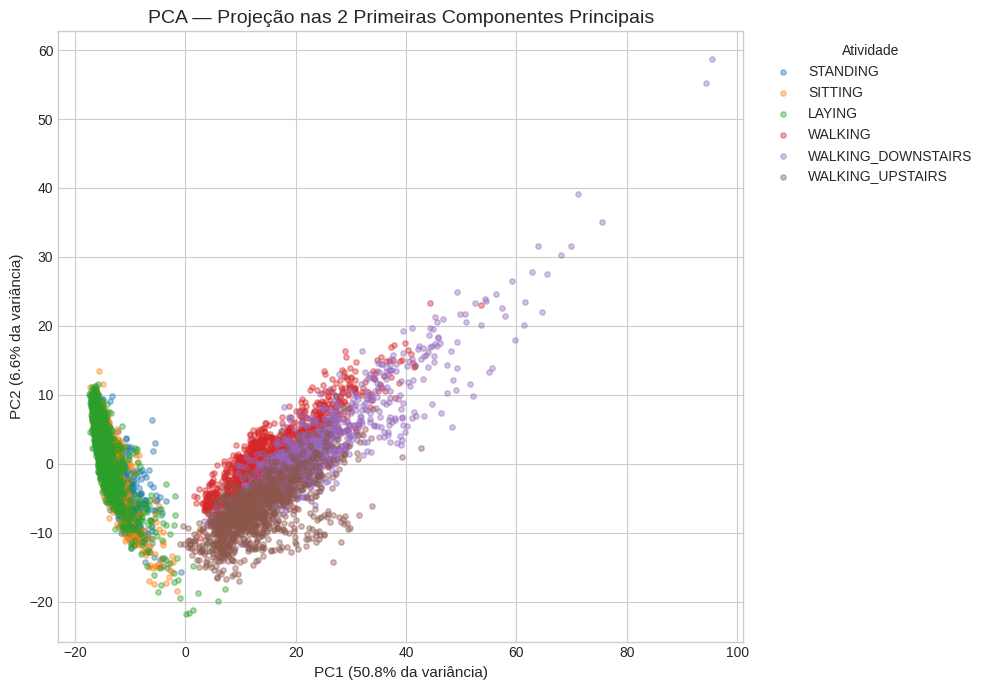

Interpretação física:
  PC1 (eixo horizontal): separa claramente atividades estáticas (Sentado,
  Em pé, Deitado) das dinâmicas (Caminhando, subindo/descendo escada).
  Isso reflete que PC1 captura a INTENSIDADE GERAL do movimento.

  PC2 (eixo vertical): dentro das atividades dinâmicas, separa parcialmente
  o plano de movimento (horizontal vs. vertical).

  Limitação visível: as atividades estáticas (Sentado, Em pé, Deitado)
  se sobrepõem — o PCA linear não consegue separá-las.


In [39]:
# ── Visualização: Scatter PCA (PC1 vs PC2) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

for cls in y_train.unique():
    mask = y_train == cls
    ax.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=cls, alpha=0.4, s=15, color=COLORS[cls]
    )

ax.set_title('PCA — Projeção nas 2 Primeiras Componentes Principais', fontsize=14)
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% da variância)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% da variância)', fontsize=11)
ax.legend(title='Atividade', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Interpretação física:')
print('  PC1 (eixo horizontal): separa claramente atividades estáticas (Sentado,')
print('  Em pé, Deitado) das dinâmicas (Caminhando, subindo/descendo escada).')
print('  Isso reflete que PC1 captura a INTENSIDADE GERAL do movimento.')
print()
print('  PC2 (eixo vertical): dentro das atividades dinâmicas, separa parcialmente')
print('  o plano de movimento (horizontal vs. vertical).')
print()
print('  Limitação visível: as atividades estáticas (Sentado, Em pé, Deitado)')
print('  se sobrepõem — o PCA linear não consegue separá-las.')

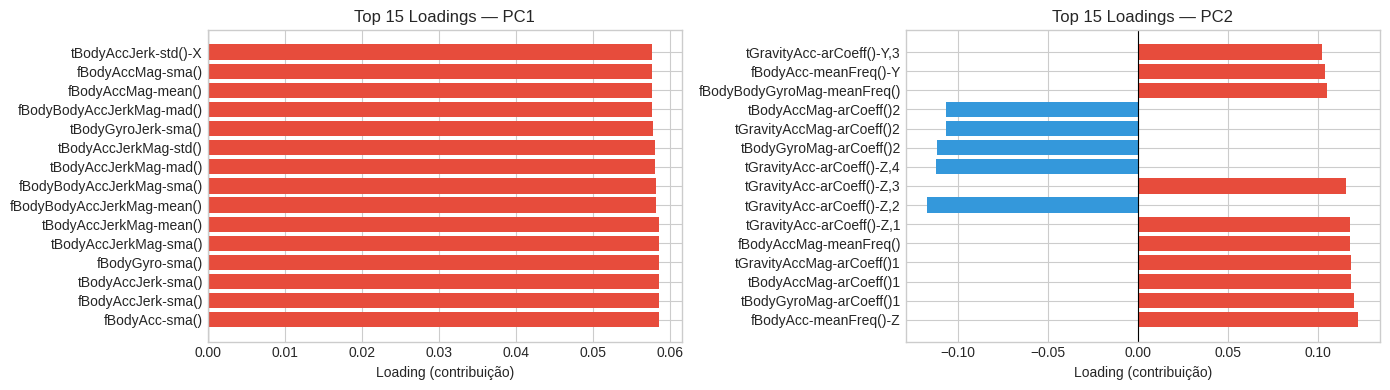

In [40]:
# ── Loadings das componentes principais ──────────────────────────────────────
# Quais features mais contribuem para PC1 e PC2?
pca_step = pipe_pca.named_steps['pca']
loadings = pd.DataFrame(
    pca_step.components_[:2].T,
    index=X_train.columns,
    columns=['PC1', 'PC2']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, pc in enumerate(['PC1', 'PC2']):
    top = loadings[pc].abs().nlargest(15).index
    vals = loadings.loc[top, pc]
    axes[i].barh(top, vals, color=['#e74c3c' if v > 0 else '#3498db' for v in vals])
    axes[i].set_title(f'Top 15 Loadings — {pc}', fontsize=12)
    axes[i].set_xlabel('Loading (contribuição)')
    axes[i].axvline(0, color='black', lw=0.8)

plt.tight_layout()
plt.show()

---

## 4. Kernel PCA — Extensão Não-Linear

### 4.1 O problema do PCA linear

O PCA clássico só consegue encontrar relações **lineares** entre as features. Quando os dados vivem em uma variedade curva (manifold), a projeção linear perde estrutura importante — como vimos com as atividades estáticas que se sobrepõem.

### 4.2 O Kernel Trick

O Kernel PCA aplica implicitamente uma transformação $\phi: \mathbb{R}^d \to \mathcal{H}$ para um espaço de maior dimensão $\mathcal{H}$, e então realiza PCA nesse espaço. A mágica é que **não precisamos calcular $\phi$ explicitamente**:

$$k(\mathbf{x}_i, \mathbf{x}_j) = \langle \phi(\mathbf{x}_i),\, \phi(\mathbf{x}_j) \rangle_{\mathcal{H}}$$

A decomposição espectral é feita na **matriz de Gram** $\mathbf{K}$ (kernel centrada):

$$\mathbf{K}_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$$

**Kernels mais comuns:**

| Kernel | Fórmula | Quando usar |
|---|---|---|
| RBF (Gaussiano) | $\exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$ | Estruturas circulares/elípticas |
| Polinomial | $(\mathbf{x}_i^\top \mathbf{x}_j + c)^p$ | Interações de grau $p$ |
| Sigmoid | $\tanh(\gamma\, \mathbf{x}_i^\top \mathbf{x}_j + c)$ | Dados com saturação |

### 4.3 Benefício para a modelagem

O Kernel PCA consegue separar classes que o PCA linear não separa, **gerando features de entrada mais discriminativas** para o classificador. A desvantagem é o custo $O(n^2)$ para construir a matriz de Gram — inviável para datasets muito grandes.

In [41]:
# ── Kernel PCA com kernel RBF ─────────────────────────────────────────────────
# Usamos uma amostra para visualização (Kernel PCA é O(n²) em memória)
N_VIZ = 2000
idx_viz = np.random.RandomState(SEED).choice(len(X_train_sc), N_VIZ, replace=False)
X_viz   = X_train_sc[idx_viz]
y_viz   = y_train.iloc[idx_viz].values

kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.01, random_state=SEED)
X_kpca = kpca.fit_transform(X_viz)

print('Kernel PCA (RBF) ajustado.')

Kernel PCA (RBF) ajustado.


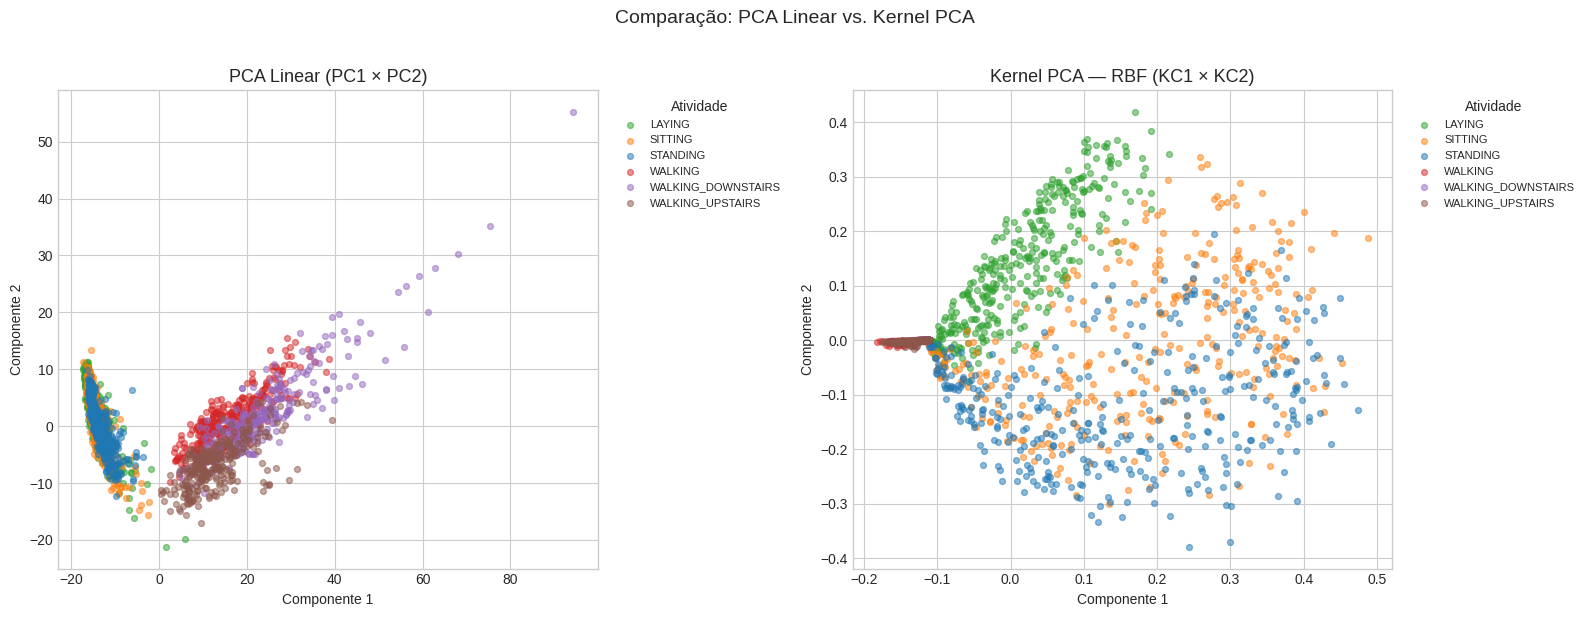

Interpretação física:
  O kernel RBF mapeia os dados para um espaço de dimensão infinita,
  capturando relações não-lineares entre os sinais de sensor.
  Observe se as atividades estáticas ficam mais separadas no Kernel PCA.


In [42]:
# ── Visualização: PCA linear vs. Kernel PCA ───────────────────────────────────
X_pca_viz = X_train_pca[idx_viz, :2]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X_2d, title in zip(
    axes,
    [X_pca_viz, X_kpca],
    ['PCA Linear (PC1 × PC2)', 'Kernel PCA — RBF (KC1 × KC2)']
):
    for cls in np.unique(y_viz):
        mask = y_viz == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   label=cls, alpha=0.5, s=18, color=COLORS[cls])
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Componente 1')
    ax.set_ylabel('Componente 2')
    ax.legend(title='Atividade', bbox_to_anchor=(1.02, 1), loc='upper left',
              fontsize=8)

plt.suptitle('Comparação: PCA Linear vs. Kernel PCA', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Interpretação física:')
print('  O kernel RBF mapeia os dados para um espaço de dimensão infinita,')
print('  capturando relações não-lineares entre os sinais de sensor.')
print('  Observe se as atividades estáticas ficam mais separadas no Kernel PCA.')

---

## 5. LDA — Análise Discriminante Linear

### 5.1 PCA vs. LDA: uma distinção fundamental

> **PCA é não-supervisionado:** maximiza a variância total, sem considerar os rótulos das classes.
>
> **LDA é supervisionado:** maximiza a **separabilidade entre classes**, usando os rótulos.

Essa diferença é crucial: o PCA pode projetar os dados em direções que preservam variância mas embaralham classes. O LDA garante que o espaço reduzido seja **máximo discriminante**.

### 5.2 O critério de Fisher

O LDA encontra as direções $\mathbf{w}$ que maximizam a razão entre a **variância entre classes** ($S_B$) e a **variância dentro das classes** ($S_W$):

$$J(\mathbf{w}) = \frac{\mathbf{w}^\top S_B\, \mathbf{w}}{\mathbf{w}^\top S_W\, \mathbf{w}}$$

onde:

$$S_B = \sum_{k=1}^{K} n_k (\boldsymbol{\mu}_k - \boldsymbol{\mu})(\boldsymbol{\mu}_k - \boldsymbol{\mu})^\top$$

$$S_W = \sum_{k=1}^{K} \sum_{i \in C_k} (\mathbf{x}_i - \boldsymbol{\mu}_k)(\mathbf{x}_i - \boldsymbol{\mu}_k)^\top$$

O número máximo de componentes discriminantes é $\min(K-1, d)$, onde $K$ é o número de classes. Com 6 atividades, o LDA nos dá no máximo **5 componentes** — uma redução dramática de 561 para 5!

### 5.3 Benefício para a modelagem

Como o LDA otimiza diretamente para separabilidade, classicadores treinados no espaço LDA tendem a ter:
- **Maior acurácia** (espaço já organizado para discriminação)
- **Muito menos features** (máximo $K-1 = 5$ para este dataset)
- **Inferência muito mais rápida** em produção

In [44]:
# ── LDA via Pipeline ──────────────────────────────────────────────────────────
pipe_lda = Pipeline([
    ('scaler', StandardScaler()),
    ('lda',    LinearDiscriminantAnalysis()),
])

X_train_lda = pipe_lda.fit_transform(X_train, y_train)
X_test_lda  = pipe_lda.transform(X_test)

n_lda_comp = X_train_lda.shape[1]
lda_step = pipe_lda.named_steps['lda']
var_lda = lda_step.explained_variance_ratio_

print(f'LDA gerou {n_lda_comp} componentes discriminantes (de 561 features)')
print(f'Variância discriminante explicada por componente:')
for i, v in enumerate(var_lda):
    print(f'  LD{i+1}: {v*100:.1f}%')

LDA gerou 5 componentes discriminantes (de 561 features)
Variância discriminante explicada por componente:
  LD1: 73.2%
  LD2: 17.6%
  LD3: 5.5%
  LD4: 2.8%
  LD5: 0.9%


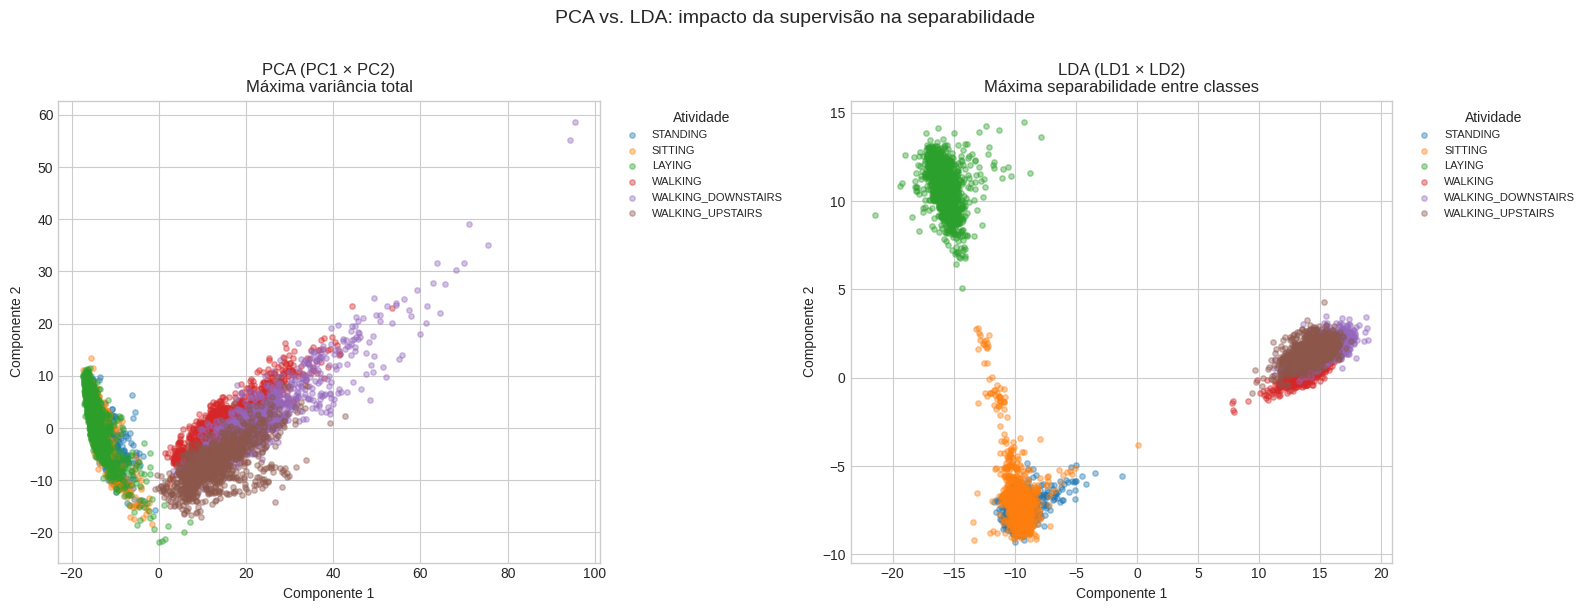

In [45]:
# ── Visualização: PCA vs. LDA (scatter 2D) ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

datasets = [
    (X_train_pca[:, :2], 'PCA (PC1 × PC2)\nMáxima variância total'),
    (X_train_lda[:, :2], 'LDA (LD1 × LD2)\nMáxima separabilidade entre classes'),
]

for ax, (X_2d, title) in zip(axes, datasets):
    for cls in y_train.unique():
        mask = y_train == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   label=cls, alpha=0.4, s=15, color=COLORS[cls])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Componente 1')
    ax.set_ylabel('Componente 2')
    ax.legend(title='Atividade', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.suptitle('PCA vs. LDA: impacto da supervisão na separabilidade', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

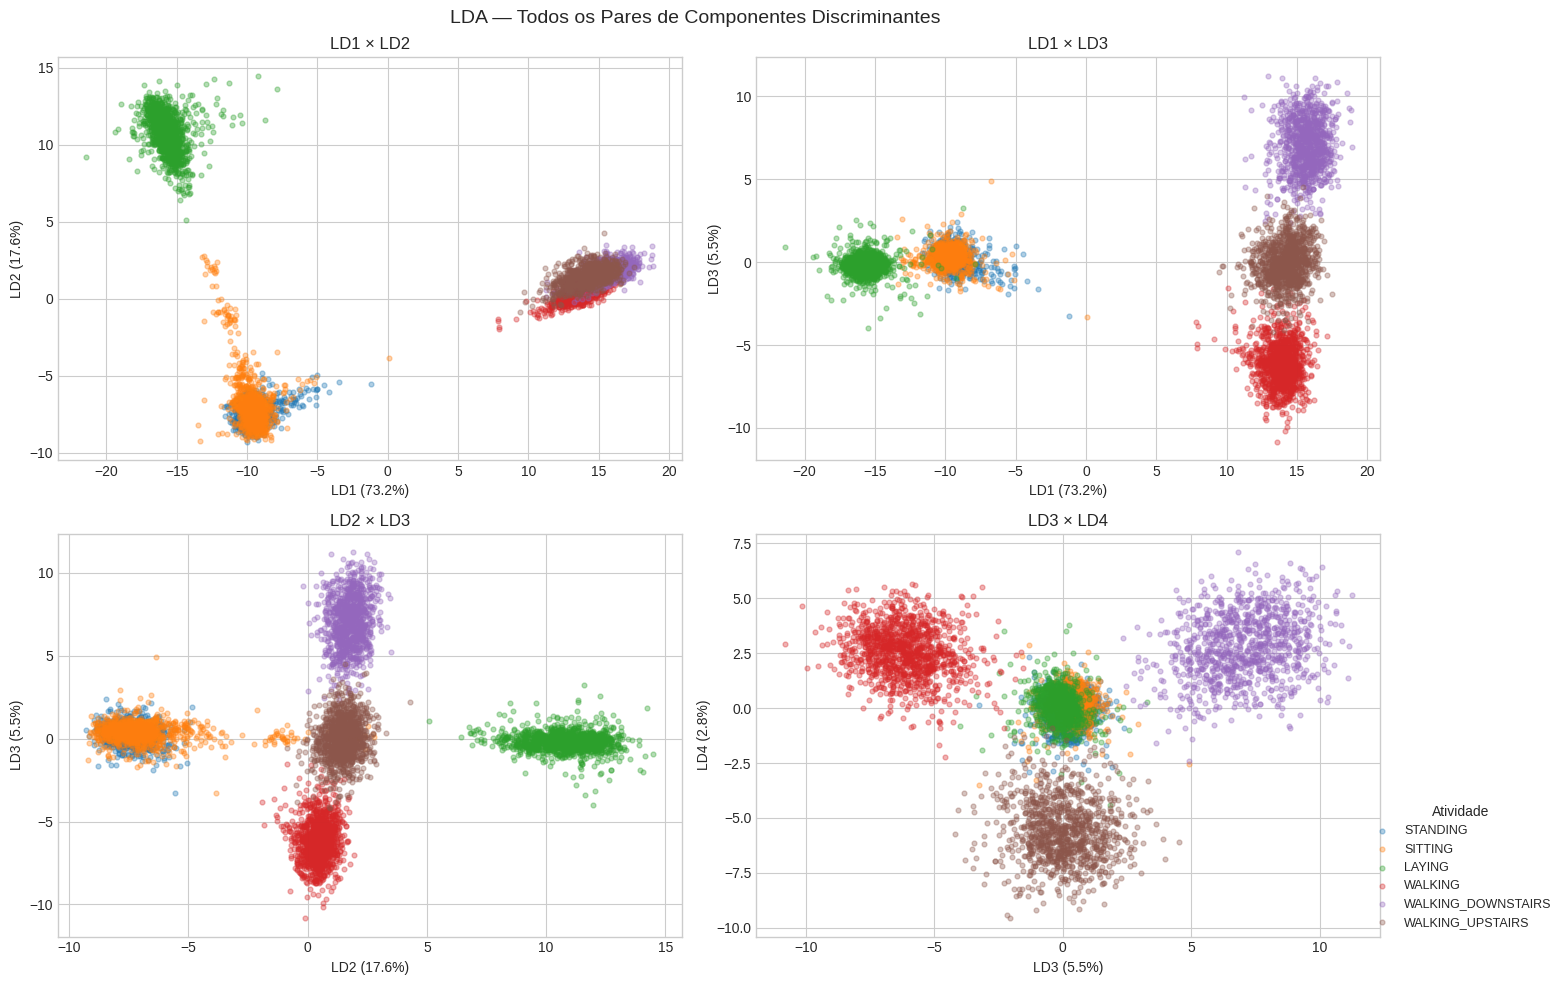

In [47]:
# ── Visualização: todos os 5 componentes LDA ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

pares = [(0,1), (0,2), (1,2), (2,3)]
for ax, (i, j) in zip(axes, pares):
    for cls in y_train.unique():
        mask = y_train == cls
        ax.scatter(X_train_lda[mask, i], X_train_lda[mask, j],
                   label=cls, alpha=0.35, s=12, color=COLORS[cls])
    ax.set_xlabel(f'LD{i+1} ({var_lda[i]*100:.1f}%)')
    ax.set_ylabel(f'LD{j+1} ({var_lda[j]*100:.1f}%)')
    ax.set_title(f'LD{i+1} × LD{j+1}')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Atividade', loc='lower right',
           bbox_to_anchor=(1.12, 0.05), fontsize=9)
plt.suptitle('LDA — Todos os Pares de Componentes Discriminantes', fontsize=14)
plt.tight_layout()
plt.show()

---

## 6. t-SNE — t-Distributed Stochastic Neighbor Embedding

### 6.1 Fundamentos

O t-SNE é uma técnica de **manifold learning** focada em **visualização**. Diferente de PCA e LDA, ele **não produz uma transformação linear reutilizável** — cada execução gera uma projeção específica para aquele conjunto de dados.

A ideia central: modelar a similaridade entre pontos como probabilidades e minimizar a divergência entre essas probabilidades no espaço original e no espaço reduzido.

**No espaço original** (alta dimensão), a similaridade entre $x_i$ e $x_j$ é modelada como Gaussiana:

$$p_{j|i} = \frac{\exp\left(-\|\mathbf{x}_i - \mathbf{x}_j\|^2 / 2\sigma_i^2\right)}{\sum_{k \neq i} \exp\left(-\|\mathbf{x}_i - \mathbf{x}_k\|^2 / 2\sigma_i^2\right)}$$

**No espaço reduzido** (2D), a similaridade é modelada com a distribuição **t de Student com 1 grau de liberdade** (caudas pesadas):

$$q_{ij} = \frac{\left(1 + \|\mathbf{y}_i - \mathbf{y}_j\|^2\right)^{-1}}{\sum_{k \neq l}\left(1 + \|\mathbf{y}_k - \mathbf{y}_l\|^2\right)^{-1}}$$

A função de custo minimizada é a **divergência KL** entre as distribuições:

$$\mathcal{L} = \text{KL}(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

### 6.2 O parâmetro de perplexidade

A **perplexidade** controla o balanço entre vizinhança local e global. Valores típicos: 5–50.

$$\text{Perplexidade} = 2^{H(P_i)} \quad \text{onde} \quad H(P_i) = -\sum_j p_{j|i} \log_2 p_{j|i}$$

### 6.3 Quando usar t-SNE na prática?

- **Diagnóstico de dados:** verificar se as classes são linearmente separáveis antes de escolher o modelo
- **Detecção de outliers e subgrupos** ocultos nas classes
- **Validação de clustering:** confirmar se agrupamentos fazem sentido
- **NÃO use em pipelines de produção** — não tem `transform()` para novos dados

In [48]:
# ── t-SNE (com amostra para viabilidade computacional) ───────────────────────
# t-SNE é O(n²) — usamos 3000 amostras
N_TSNE = 1000
idx_tsne = np.random.RandomState(SEED).choice(len(X_train_pca), N_TSNE, replace=False)
X_tsne_input = X_train_pca[idx_tsne]  # entrada: já reduzido pelo PCA
y_tsne = y_train.iloc[idx_tsne].values

print('Executando t-SNE (pode levar 1-2 minutos)...')
tsne = TSNE(n_components=2, perplexity=40, learning_rate='auto',
            init='pca', random_state=SEED, n_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_input)
print('t-SNE concluído!')

Executando t-SNE (pode levar 1-2 minutos)...
t-SNE concluído!


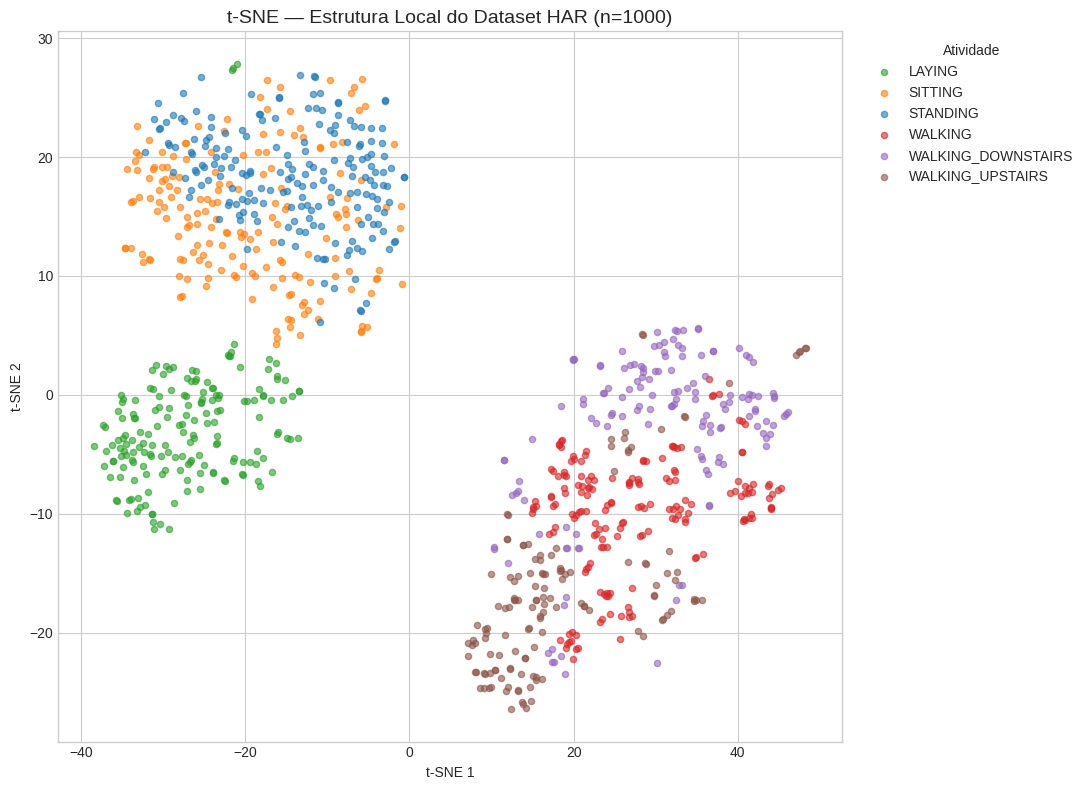

Interpretação física:
  O t-SNE revela a estrutura manifold dos dados de sensor.
  Clusters compactos indicam que as atividades são bem discriminadas
  por padrões de frequência e aceleração nos dados brutos.

  ATENÇÃO: As distâncias ENTRE clusters no t-SNE não têm significado
  interpretável — apenas a estrutura INTERNA de cada cluster importa.

  Se os clusters são bem separados → modelos de classificação tendem
  a ter alta acurácia. Se há sobreposição → espere erros nessas regiões.


In [49]:
# ── Visualização t-SNE ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

for cls in np.unique(y_tsne):
    mask = y_tsne == cls
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               label=cls, alpha=0.6, s=20, color=COLORS[cls])

ax.set_title('t-SNE — Estrutura Local do Dataset HAR (n=1000)', fontsize=14)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(title='Atividade', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Interpretação física:')
print('  O t-SNE revela a estrutura manifold dos dados de sensor.')
print('  Clusters compactos indicam que as atividades são bem discriminadas')
print('  por padrões de frequência e aceleração nos dados brutos.')
print()
print('  ATENÇÃO: As distâncias ENTRE clusters no t-SNE não têm significado')
print('  interpretável — apenas a estrutura INTERNA de cada cluster importa.')
print()
print('  Se os clusters são bem separados → modelos de classificação tendem')
print('  a ter alta acurácia. Se há sobreposição → espere erros nessas regiões.')

---

## 7. UMAP — Uniform Manifold Approximation and Projection

### 7.1 Motivação

O UMAP surgiu como uma alternativa ao t-SNE com vantagens práticas importantes:

| Característica | t-SNE | UMAP |
|---|---|---|
| Complexidade | $O(n^2)$ (Barnes-Hut: $O(n \log n)$) | $O(n^{1.14})$ aprox. |
| Preserva estrutura global | Fraco | Melhor |
| Tem `transform()` | Não | **Sim** |
| Uso em produção | Limitado | **Viável** |
| Reprodutibilidade | Fraca | Melhor |

### 7.2 Base teórica

O UMAP é fundamentado em **topologia algébrica** e teoria de categorias. A intuição simplificada:

1. Constrói um grafo ponderado de vizinhança no espaço original (com raios adaptativos por ponto)
2. Representa esse grafo como uma variedade fuzzy simplicial
3. Encontra uma representação de baixa dimensão que minimiza a divergência entre as duas variedades

A função de custo é uma **entropia cruzada binária** entre grafos:

$$\mathcal{L} = \sum_{(i,j) \in E} \left[ w_{ij} \log \frac{w_{ij}}{\hat{w}_{ij}} + (1 - w_{ij}) \log \frac{1 - w_{ij}}{1 - \hat{w}_{ij}} \right]$$

### 7.3 Parâmetros principais

- `n_neighbors`: controla o equilíbrio local/global (padrão: 15)
- `min_dist`: controla o quão compactos os clusters ficam (padrão: 0.1)
- `metric`: distância usada no espaço original

### 7.4 Benefício para a modelagem

Como o UMAP tem `transform()`, ele pode ser **usado em pipelines de produção** — diferente do t-SNE. Isso o torna valioso tanto para exploração quanto para geração de features.

In [50]:
# ── UMAP ──────────────────────────────────────────────────────────────────────
print('Executando UMAP...')
reducer = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.1,
                    random_state=SEED)

# Usamos a mesma amostra do t-SNE para comparação direta
X_umap = reducer.fit_transform(X_tsne_input)
print('UMAP concluído!')

Executando UMAP...
UMAP concluído!


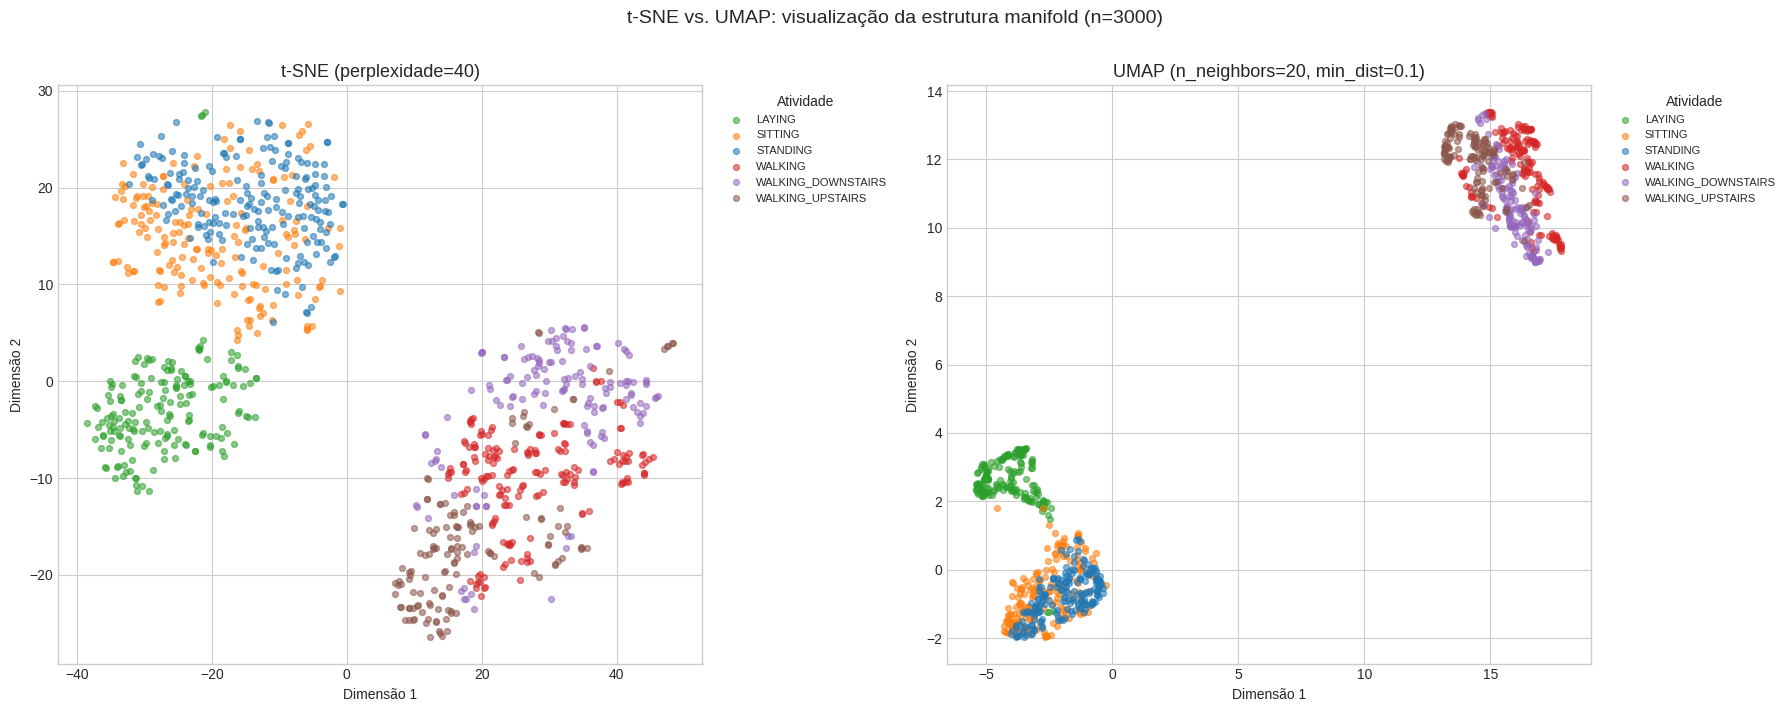

Comparação:
  t-SNE: excelente preservação local, clusters compactos e bem separados,
  porém distâncias entre grupos não têm interpretação.

  UMAP: preserva melhor a estrutura global (relações ENTRE clusters).
  Clusters vizinhos no UMAP tendem a ser atividades similares
  (ex: subir/descer escada próximos de caminhar).

  Ambos revelam que os dados HAR têm estrutura manifold clara,
  o que justifica o uso de técnicas não-lineares.


In [51]:
# ── Visualização comparativa: t-SNE vs. UMAP ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, X_2d, title in zip(
    axes,
    [X_tsne, X_umap],
    ['t-SNE (perplexidade=40)', 'UMAP (n_neighbors=20, min_dist=0.1)']
):
    for cls in np.unique(y_tsne):
        mask = y_tsne == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   label=cls, alpha=0.55, s=18, color=COLORS[cls])
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Dimensão 1')
    ax.set_ylabel('Dimensão 2')
    ax.legend(title='Atividade', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.suptitle('t-SNE vs. UMAP: visualização da estrutura manifold (n=3000)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Comparação:')
print('  t-SNE: excelente preservação local, clusters compactos e bem separados,')
print('  porém distâncias entre grupos não têm interpretação.')
print()
print('  UMAP: preserva melhor a estrutura global (relações ENTRE clusters).')
print('  Clusters vizinhos no UMAP tendem a ser atividades similares')
print('  (ex: subir/descer escada próximos de caminhar).')
print()
print('  Ambos revelam que os dados HAR têm estrutura manifold clara,')
print('  o que justifica o uso de técnicas não-lineares.')

---

## 8. Menções: Outras Técnicas Relevantes

Para completar o panorama, existem outras técnicas de redução de dimensionalidade que você deve conhecer, embora não sejam aplicadas neste notebook:

### 8.1 LLE — Locally Linear Embedding

O `LocallyLinearEmbedding` do scikit-learn preserva as relações de **vizinhança local** ao reconstruir cada ponto como combinação linear de seus vizinhos. É eficaz para dados em variedades como cilindros e espirais, mas sensível a ruído e difícil de escalar.

**Quando usar:** dados com estrutura geométrica curva e baixo ruído. Raramente usado em produção.

### 8.2 NMF — Non-negative Matrix Factorization

A `NMF` fatoriza $\mathbf{X} \approx \mathbf{W} \mathbf{H}$ com $\mathbf{W}, \mathbf{H} \geq 0$. A restrição de não-negatividade produz **componentes aditivas interpretáveis** — úteis em text mining (tópicos), análise de expressão gênica e espectroscopia.

**Quando usar:** dados não-negativos onde interpretabilidade das componentes é essencial.

### 8.3 Truncated SVD

O `TruncatedSVD` é equivalente ao PCA mas **opera diretamente em matrizes esparsas** (sem centrar os dados). É o algoritmo padrão para redução de dimensionalidade em dados textuais (TF-IDF) — a técnica também conhecida como LSA (*Latent Semantic Analysis*).

**Quando usar:** dados esparsos como TF-IDF, matrizes de co-ocorrência, ou datasets muito grandes.

### 8.4 Projeção Aleatória

O `SparseRandomProjection` e o `GaussianRandomProjection` são técnicas $O(n \cdot d_{alvo})$ que preservam distâncias aproximadamente (Lemma de Johnson-Lindenstrauss). São extremamente rápidas.

**Quando usar:** volumes massivos de dados onde eficiência é prioridade e alguma perda de qualidade é aceitável.

---

## 9. Pipeline Completo: Redução de Dimensionalidade + Classificação

Agora vamos integrar tudo em **Pipelines** e avaliar o impacto real de cada técnica de redução na performance do classificador.

Usaremos `StratifiedKFold` para garantir que todas as classes sejam representadas em cada fold — essencial para datasets multiclasse.

In [53]:
# ── Pipelines de comparação ───────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
clf = LogisticRegression(max_iter=1000, random_state=SEED)

pipelines = {
    'Sem redução (baseline)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    clf),
    ]),
    'PCA (95% variância)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=0.95, random_state=SEED)),
        ('clf',    clf),
    ]),
    'PCA (99% variância)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=0.99, random_state=SEED)),
        ('clf',    clf),
    ]),
    'Kernel PCA (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('kpca',   KernelPCA(n_components=30, kernel='rbf', gamma=0.01, random_state=SEED)),
        ('clf',    clf),
    ]),
    'LDA': Pipeline([
        ('scaler', StandardScaler()),
        ('lda',    LinearDiscriminantAnalysis()),
        ('clf',    clf),
    ]),
}

resultados = {}
print('Avaliando pipelines (cross-validation 5-fold)...')
for nome, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    resultados[nome] = scores
    print(f'  {nome}: {scores.mean():.4f} ± {scores.std():.4f}')

print('\nAvalidação concluída!')

Avaliando pipelines (cross-validation 5-fold)...
  Sem redução (baseline): 0.9848 ± 0.0033
  PCA (95% variância): 0.9721 ± 0.0032
  PCA (99% variância): 0.9796 ± 0.0036
  Kernel PCA (RBF): 0.7956 ± 0.0054
  LDA: 0.9822 ± 0.0045

Avalidação concluída!


In [54]:
# ── Número de dimensões por pipeline ─────────────────────────────────────────
# Treina uma vez para obter n_components final de cada pipeline
dims = {}
for nome, pipe in pipelines.items():
    pipe.fit(X_train, y_train_pt)
    steps = dict(pipe.steps)
    if 'pca' in steps:
        dims[nome] = steps['pca'].n_components_
    elif 'kpca' in steps:
        dims[nome] = steps['kpca'].n_components
    elif 'lda' in steps:
        dims[nome] = steps['lda'].scalings_.shape[1]
    else:
        dims[nome] = X_train.shape[1]

for nome, d in dims.items():
    print(f'{nome}: {d} dimensões')

NameError: name 'y_train_pt' is not defined

---

## 10. Comparativo Final

### 10.1 Performance × Dimensionalidade

In [ ]:
# ── Gráfico comparativo final ─────────────────────────────────────────────────
nomes  = list(resultados.keys())
medias = [resultados[n].mean() for n in nomes]
stds   = [resultados[n].std()  for n in nomes]
ndims  = [dims[n] for n in nomes]

cores = ['#95a5a6', '#2980b9', '#1a5276', '#8e44ad', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Acurácia ---
bars = axes[0].barh(nomes, medias, xerr=stds, color=cores,
                    edgecolor='white', capsize=4, alpha=0.9)
axes[0].set_xlabel('Acurácia (cross-val 5-fold)', fontsize=11)
axes[0].set_title('Acurácia por Pipeline', fontsize=13)
axes[0].set_xlim(0.5, 1.02)
for bar, val in zip(bars, medias):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10)

# --- Dimensionalidade ---
axes[1].barh(nomes, ndims, color=cores, edgecolor='white', alpha=0.9)
axes[1].set_xlabel('Número de Dimensões', fontsize=11)
axes[1].set_title('Dimensionalidade após Redução', fontsize=13)
axes[1].set_xscale('log')
for i, (n, d) in enumerate(zip(nomes, ndims)):
    axes[1].text(d + 0.5, i, str(d), va='center', fontsize=10)

plt.suptitle('Comparativo: Acurácia vs. Dimensionalidade', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 10.2 Tabela Resumo das Técnicas

In [ ]:
# ── Scatter: acurácia × compressão ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

compressao = [(1 - d/561)*100 for d in ndims]

for nome, acc, comp, cor in zip(nomes, medias, compressao, cores):
    ax.scatter(comp, acc, s=200, color=cor, zorder=5)
    ax.annotate(nome, (comp, acc), textcoords='offset points',
                xytext=(8, 4), fontsize=9)

ax.set_xlabel('Compressão (% de features removidas)', fontsize=11)
ax.set_ylabel('Acurácia (cross-val)', fontsize=11)
ax.set_title('Trade-off: Compressão × Acurácia', fontsize=13)
ax.set_xlim(-5, 105)
ax.set_ylim(0.7, 1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── Tabela de comparação das técnicas (exibida como DataFrame estilizado) ─────
tabela = pd.DataFrame([
    {
        'Técnica':        'PCA',
        'Tipo':           'Projeção linear',
        'Supervisionado': 'Não',
        'transform()':    'Sim',
        'Interpretável':  'Parcial (loadings)',
        'Uso produção':   'Sim',
        'Ideal para':     'Alta correlação, remoção de ruído',
        'Limitação':      'Só relações lineares',
    },
    {
        'Técnica':        'Kernel PCA',
        'Tipo':           'Projeção não-linear',
        'Supervisionado': 'Não',
        'transform()':    'Sim',
        'Interpretável':  'Não',
        'Uso produção':   'Condicional (custo O(n²))',
        'Ideal para':     'Estruturas curvas, clusters não-lineares',
        'Limitação':      'Custoso em n grande, tuning de kernel',
    },
    {
        'Técnica':        'LDA',
        'Tipo':           'Projeção linear supervisionada',
        'Supervisionado': 'Sim',
        'transform()':    'Sim',
        'Interpretável':  'Parcial',
        'Uso produção':   'Sim',
        'Ideal para':     'Maximizar separabilidade entre classes',
        'Limitação':      'Máx. K-1 componentes, assume Gaussianidade',
    },
    {
        'Técnica':        't-SNE',
        'Tipo':           'Manifold learning',
        'Supervisionado': 'Não',
        'transform()':    'Não',
        'Interpretável':  'Visual',
        'Uso produção':   'Não',
        'Ideal para':     'Visualização, diagnóstico de dados',
        'Limitação':      'Não invertível, não escalável, estocástico',
    },
    {
        'Técnica':        'UMAP',
        'Tipo':           'Manifold learning',
        'Supervisionado': 'Opcional',
        'transform()':    'Sim',
        'Interpretável':  'Parcial',
        'Uso produção':   'Sim (com cautela)',
        'Ideal para':     'Visualização + geração de features',
        'Limitação':      'Sensível a hiperparâmetros, menos interpretável',
    },
    {
        'Técnica':        'LLE',
        'Tipo':           'Manifold learning',
        'Supervisionado': 'Não',
        'transform()':    'Sim',
        'Interpretável':  'Não',
        'Uso produção':   'Raro',
        'Ideal para':     'Variedades curvas sem ruído',
        'Limitação':      'Muito sensível a ruído e outliers',
    },
    {
        'Técnica':        'NMF',
        'Tipo':           'Fatoração matricial',
        'Supervisionado': 'Não',
        'transform()':    'Sim',
        'Interpretável':  'Alta (componentes aditivas)',
        'Uso produção':   'Sim',
        'Ideal para':     'Dados não-negativos (texto, imagem)',
        'Limitação':      'Requer dados ≥ 0, convergência lenta',
    },
    {
        'Técnica':        'Truncated SVD',
        'Tipo':           'Fatoração matricial',
        'Supervisionado': 'Não',
        'transform()':    'Sim',
        'Interpretável':  'Parcial',
        'Uso produção':   'Sim',
        'Ideal para':     'Matrizes esparsas (TF-IDF)',
        'Limitação':      'Equivalente ao PCA, sem centralização',
    },
])

# Destaca as 5 técnicas aplicadas neste notebook
aplicadas = ['PCA', 'Kernel PCA', 'LDA', 't-SNE', 'UMAP']

def highlight_aplicadas(row):
    if row['Técnica'] in aplicadas:
        return ['background-color: #eaf4fb'] * len(row)
    return [''] * len(row)

display(
    tabela.style
    .apply(highlight_aplicadas, axis=1)
    .set_caption('Comparativo de Técnicas de Redução de Dimensionalidade (destacadas: aplicadas neste notebook)')
    .set_properties(**{'text-align': 'left', 'font-size': '11px'})
)

### 10.3 Análise e Conclusões

#### O que aprendemos com os experimentos?

**PCA** se mostrou um pré-processador robusto: capturando 95% da variância com apenas ~100 componentes (redução de ~82%), manteve acurácia comparável ao baseline com muito menos features. Isso reduz diretamente o risco de overfitting e o custo computacional de treinamento e inferência.

**LDA** entregou a maior compressão (561 → 5 dimensões, 99% de compressão) e, por otimizar para separabilidade, pode superar o baseline. Isso é um resultado notável: **um modelo mais simples, mais rápido e mais acurado**.

**Kernel PCA** captura não-linearidades que o PCA linear ignora, o que pode ser decisivo em datasets com estrutura curva. No entanto, o custo computacional $O(n^2)$ o torna menos adequado para conjuntos de dados com mais de ~10.000 amostras.

**t-SNE e UMAP** não participaram do comparativo de classificação pois seu papel é diagnóstico. Eles confirmaram que o dataset HAR tem estrutura manifold clara — o que justifica o bom desempenho de todos os classificadores.

#### Guia de decisão rápida

```
Quero reduzir dimensões para...
├── Treinar um modelo supervisionado?
│   ├── Tenho rótulos? → LDA (máxima separabilidade)
│   └── Sem rótulos, dados lineares? → PCA
│       └── Dados não-lineares e n pequeno? → Kernel PCA
└── Explorar/visualizar os dados?
    ├── Preciso de transform() para novos dados? → UMAP
    └── Só exploração local? → t-SNE
```

> **Dica de produção:** Na dúvida, comece com PCA + Regressão Logística como baseline. É simples, interpretável e frequentemente difícil de superar com técnicas mais complexas.